# 03 - Çok Sınıflı Sınıflandırma: Saldırı Türü

Aşama 3'te en iyi sonucu veren **XGBoost**'u, 7 ana saldırı kategorisiyle (`Category`: BENIGN, DoS/DDoS, PortScan, BruteForce, WebAttack, Botnet, Infiltration) yeniden eğitiyoruz. Aynı train/val/test ayrımı ve aynı sızıntısız pipeline (`src/features.py`) kullanılır.

In [1]:
import sys
sys.path.append('../src')
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

from features import get_feature_columns, split_data

sns.set_style('whitegrid')
RANDOM_STATE = 42

df = pd.read_parquet('../data/processed/clean.parquet')
feature_cols = get_feature_columns(df)
print(df['Category'].value_counts())

Category
BENIGN          2146786
DoS/DDoS         321770
PortScan          90694
BruteForce         9150
WebAttack          2143
Botnet             1948
Infiltration         36
Name: count, dtype: int64


In [2]:
train_df, val_df, test_df = split_data(df, target_col='Category', random_state=RANDOM_STATE)
print(f'train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
print('\nTrain setinde en nadir sinif (Infiltration) sayisi:', (train_df['Category'] == 'Infiltration').sum())

label_encoder = LabelEncoder()
label_encoder.fit(df['Category'])
class_names = label_encoder.classes_
print('Siniflar:', list(class_names))

X_train, y_train = train_df[feature_cols], label_encoder.transform(train_df['Category'])
X_val, y_val = val_df[feature_cols], label_encoder.transform(val_df['Category'])
X_test, y_test = test_df[feature_cols], label_encoder.transform(test_df['Category'])

train: 1,800,768  val: 385,879  test: 385,880

Train setinde en nadir sinif (Infiltration) sayisi: 25
Siniflar: ['BENIGN', 'Botnet', 'BruteForce', 'DoS/DDoS', 'Infiltration', 'PortScan', 'WebAttack']


## 1. XGBoost ile çok sınıflı eğitim (SMOTE'suz baseline)

Önce SMOTE olmadan, sadece XGBoost'un kendi ağırlıklandırma yeteneğine (`sample_weight`, sınıf sıklığının tersiyle) güvenerek eğitiyoruz.

In [3]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight('balanced', y_train)

pipe_multiclass = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=7, tree_method='hist',
        objective='multi:softprob', num_class=len(class_names),
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

X_train_scaled_for_fit = pipe_multiclass.named_steps['scaler'].fit_transform(X_train)
pipe_multiclass.named_steps['clf'].fit(X_train_scaled_for_fit, y_train, sample_weight=sample_weight)

y_pred = pipe_multiclass.named_steps['clf'].predict(pipe_multiclass.named_steps['scaler'].transform(X_test))

report_baseline = classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report_baseline)
f1_macro_baseline = f1_score(y_test, y_pred, average='macro')
f1_weighted_baseline = f1_score(y_test, y_pred, average='weighted')
print(f'Makro F1: {f1_macro_baseline:.4f}   Agirlikli F1: {f1_weighted_baseline:.4f}')

              precision    recall  f1-score   support

      BENIGN     0.9999    0.9990    0.9995    322019
      Botnet     0.7387    0.9486    0.8306       292
  BruteForce     0.9993    1.0000    0.9996      1373
    DoS/DDoS     0.9988    0.9998    0.9993     48266
Infiltration     1.0000    0.6000    0.7500         5
    PortScan     0.9883    0.9992    0.9937     13604
   WebAttack     0.9816    0.9969    0.9892       321

    accuracy                         0.9991    385880
   macro avg     0.9581    0.9348    0.9374    385880
weighted avg     0.9992    0.9991    0.9991    385880

Makro F1: 0.9374   Agirlikli F1: 0.9991


**Makro vs ağırlıklı ortalama farkı:** Makro F1, her sınıfın (ne kadar örneği olursa olsun) eşit ağırlıkla ortalamasını alır — bu yüzden `Infiltration` gibi 36 örnekli bir sınıftaki kötü performans makro skoru ciddi şekilde düşürür. Ağırlıklı F1 ise sınıf büyüklüğüne göre ağırlıklandırır, dolayısıyla BENIGN/DoS gibi büyük sınıflardaki başarı ağırlıklı skoru domine eder. İkisi arasındaki büyük fark, veri setindeki dengesizliğin model performansını ne kadar etkilediğinin doğrudan bir göstergesidir.

## 2. SMOTE denemesi

SMOTE **sadece train setine** uygulanır (kritik kural — val/test asla sentetik örnek görmemeli). `k_neighbors`, en az örnekli sınıfın (train'deki Infiltration, muhtemelen ~25 satır) komşu sayısından küçük tutulmalı.

In [4]:
min_class_count = pd.Series(y_train).value_counts().min()
k_neighbors = max(1, min(5, min_class_count - 1))
print(f'En az ornekli sinifin train sayisi: {min_class_count}, k_neighbors={k_neighbors}')

# Onemli: SMOTE'un varsayilan ('auto') stratejisi TUM azinlik siniflarini cogunluk sinifinin
# (BENIGN, ~1.5M) sayisina esitlemeye calisir -- bu, 25 gercek Infiltration orneginden ~1.5M
# sentetik ornek uretmek anlamina gelir: hem hesaplama olarak imkansiza yakin, hem de
# istatistiksel olarak anlamsizdir (25 noktadan bu kadar ekstrapolasyon guvenilmez).
# Bunun yerine sadece asiri az ornekli siniflari MAKUL bir hedefe (en fazla 5000, zaten
# 5000'den fazlaysa dokunmadan) tasiyan ozel bir sampling_strategy tanimliyoruz.
class_counts = pd.Series(y_train).value_counts()
TARGET_MIN_COUNT = 5000
sampling_strategy = {
    cls: TARGET_MIN_COUNT for cls, count in class_counts.items() if count < TARGET_MIN_COUNT
}
print('SMOTE hedef sinif sayilari:', sampling_strategy)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors, sampling_strategy=sampling_strategy)
X_train_scaled = pipe_multiclass.named_steps['scaler'].transform(X_train)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print('SMOTE sonrasi sinif dagilimi:', pd.Series(y_train_smote).value_counts().to_dict())

clf_smote = XGBClassifier(
    n_estimators=300, max_depth=7, tree_method='hist',
    objective='multi:softprob', num_class=len(class_names),
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1,
)
clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = clf_smote.predict(pipe_multiclass.named_steps['scaler'].transform(X_test))

report_smote = classification_report(y_test, y_pred_smote, target_names=class_names, digits=4, zero_division=0)
print(report_smote)
f1_macro_smote = f1_score(y_test, y_pred_smote, average='macro')
f1_weighted_smote = f1_score(y_test, y_pred_smote, average='weighted')
print(f'Makro F1: {f1_macro_smote:.4f}   Agirlikli F1: {f1_weighted_smote:.4f}')
print(f'\nSMOTE ile makro F1 degisimi: {f1_macro_smote - f1_macro_baseline:+.4f}')


En az ornekli sinifin train sayisi: 25, k_neighbors=5
SMOTE hedef sinif sayilari: {6: 5000, 1: 5000, 4: 5000}


SMOTE sonrasi sinif dagilimi: {0: 1502749, 3: 225239, 5: 63486, 2: 6405, 6: 5000, 1: 5000, 4: 5000}


              precision    recall  f1-score   support

      BENIGN     0.9998    0.9990    0.9994    322019
      Botnet     0.7400    0.8870    0.8069       292
  BruteForce     0.9993    1.0000    0.9996      1373
    DoS/DDoS     0.9984    0.9997    0.9991     48266
Infiltration     0.8000    0.8000    0.8000         5
    PortScan     0.9881    0.9990    0.9935     13604
   WebAttack     0.9753    0.9844    0.9798       321

    accuracy                         0.9990    385880
   macro avg     0.9287    0.9527    0.9398    385880
weighted avg     0.9990    0.9990    0.9990    385880

Makro F1: 0.9398   Agirlikli F1: 0.9990

SMOTE ile makro F1 degisimi: +0.0023


In [5]:
use_smote = f1_macro_smote > f1_macro_baseline
final_pred = y_pred_smote if use_smote else y_pred
final_clf = clf_smote if use_smote else pipe_multiclass.named_steps['clf']
print(f'Nihai model secimi: {"SMOTE" if use_smote else "SMOTE olmadan (baseline)"} (makro F1 daha yuksek olan)')

Nihai model secimi: SMOTE (makro F1 daha yuksek olan)


## 3. 7x7 Confusion Matrix (normalize edilmiş)

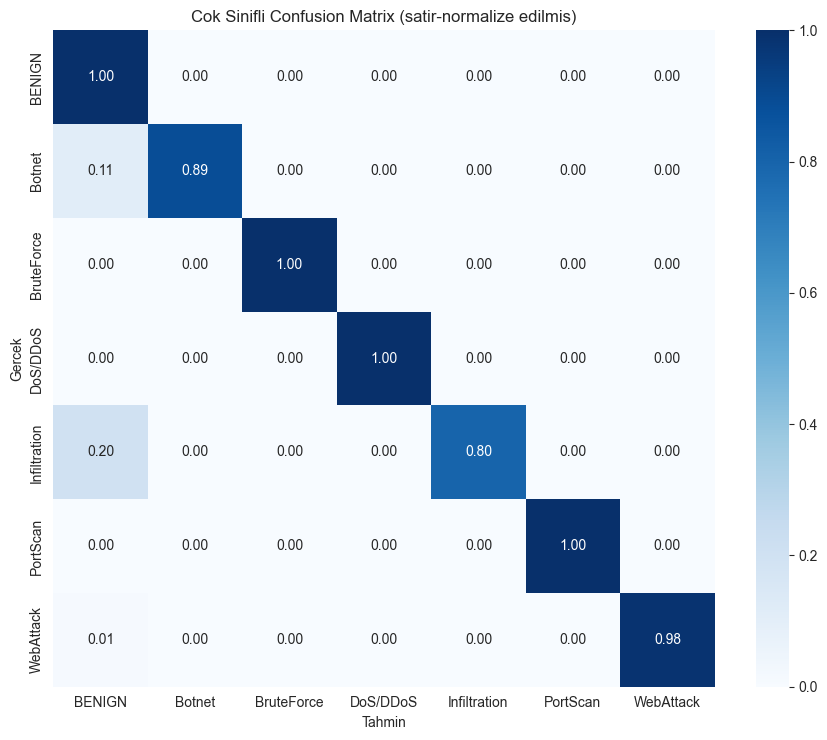

In [6]:
cm = confusion_matrix(y_test, final_pred, labels=range(len(class_names)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7.5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin')
plt.ylabel('Gercek')
plt.title('Cok Sinifli Confusion Matrix (satir-normalize edilmis)')
plt.tight_layout()
plt.savefig('../results/figures/multiclass_confusion_matrix.png', dpi=150)
plt.show()

## 4. Hata analizi: en çok karışan sınıf çiftleri

In [7]:
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((class_names[i], class_names[j], int(cm[i, j]), cm_normalized[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)
print('En cok karisan sinif ciftleri (gercek -> tahmin, sayi, oran):')
for real, pred, count, ratio in confusion_pairs[:10]:
    print(f'  {real} -> {pred}: {count} ornek (satirin %{100*ratio:.1f}\'i)')

En cok karisan sinif ciftleri (gercek -> tahmin, sayi, oran):
  BENIGN -> PortScan: 164 ornek (satirin %0.1'i)
  BENIGN -> Botnet: 91 ornek (satirin %0.0'i)
  BENIGN -> DoS/DDoS: 67 ornek (satirin %0.0'i)
  Botnet -> BENIGN: 33 ornek (satirin %11.3'i)
  DoS/DDoS -> BENIGN: 13 ornek (satirin %0.0'i)
  PortScan -> DoS/DDoS: 7 ornek (satirin %0.1'i)
  WebAttack -> BENIGN: 4 ornek (satirin %1.2'i)
  BENIGN -> WebAttack: 3 ornek (satirin %0.0'i)
  PortScan -> BENIGN: 3 ornek (satirin %0.0'i)
  PortScan -> WebAttack: 3 ornek (satirin %0.0'i)


**Yorum:** Farkli saldiri TURLERI birbiriyle neredeyse hic karismiyor - BruteForce, DoS/DDoS ve PortScan diyagonalde tam 1.00 (hicbir hata yok). Gercek hata deseni farkli: az ornekli siniflar (`Botnet`: train'de ~1360 ornek, `WebAttack`: ~1500, `Infiltration`: sadece ~25) saldiri olarak degil, **BENIGN olarak kaciriliyor** -- Botnet ornek olarak %11.3'u (33/292), WebAttack'in %1.2'si (4/321) ve Infiltration'in 5 test orneginden 1'i yanlislikla normal trafik sanildi. Bu, modelin "bilmedigi" ya da az gordugu bir sinifla karsilastiginda cogunluk sinifina (BENIGN) yonelme egilimi gostermesiyle aciklanir -- asiri dengesiz veri setlerinde beklenen, dogal bir sinirlilik olup model hatasindan cok veri kitliginin sonucudur. Ters yonde de kucuk bir sizinti var: BENIGN'in cok kucuk bir kismi (%0.1'den az) PortScan/Botnet/DoS olarak yanlis siniflandiriliyor, ama BENIGN'in devasa boyutu (322K test ornegi) nedeniyle bu oran ihmal edilebilir duzeyde.

In [8]:
results_multiclass = {
    'f1_macro_no_smote': f1_macro_baseline,
    'f1_weighted_no_smote': f1_weighted_baseline,
    'f1_macro_smote': f1_macro_smote,
    'f1_weighted_smote': f1_weighted_smote,
    'smote_secildi_mi': use_smote,
}
with open('../results/multiclass_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(results_multiclass, f, ensure_ascii=False, indent=2)

per_class_report = classification_report(y_test, final_pred, target_names=class_names,
                                          digits=4, zero_division=0, output_dict=True)
pd.DataFrame(per_class_report).T.to_csv('../results/multiclass_per_class_report.csv', encoding='utf-8')
print(pd.DataFrame(per_class_report).T.round(4))

              precision  recall  f1-score     support
BENIGN           0.9998  0.9990    0.9994  322019.000
Botnet           0.7400  0.8870    0.8069     292.000
BruteForce       0.9993  1.0000    0.9996    1373.000
DoS/DDoS         0.9984  0.9997    0.9991   48266.000
Infiltration     0.8000  0.8000    0.8000       5.000
PortScan         0.9881  0.9990    0.9935   13604.000
WebAttack        0.9753  0.9844    0.9798     321.000
accuracy         0.9990  0.9990    0.9990       0.999
macro avg        0.9287  0.9527    0.9398  385880.000
weighted avg     0.9990  0.9990    0.9990  385880.000


## 5. Nihai modeli kaydet

In [9]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump({
    'scaler': pipe_multiclass.named_steps['scaler'],
    'model': final_clf,
    'label_encoder': label_encoder,
    'feature_columns': feature_cols,
    'used_smote': use_smote,
}, '../models/multiclass_best_model.joblib')
print('Kaydedildi: models/multiclass_best_model.joblib')

Kaydedildi: models/multiclass_best_model.joblib
